## Atlases 

* atlas surface plots via neuromaps.transfomrs.mni_to_fsaverage on atlas_mni_labels look weird 

Problems:
- missing parcel --> read in connectome.csv with `header=None`!

In [3]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

base_folder = op.join(bids_folder, 'derivatives' ,'dwi_connectome')

In [4]:
glasser_atlas_file = op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/GlasserParcellationAtlas_MNI/HCP-MMP1_on_MNI152_ICBM2009a_nlin.nii.gz')
glasser_mni = nib.load(glasser_atlas_file)
len(np.unique(glasser_mni.get_fdata()))


181

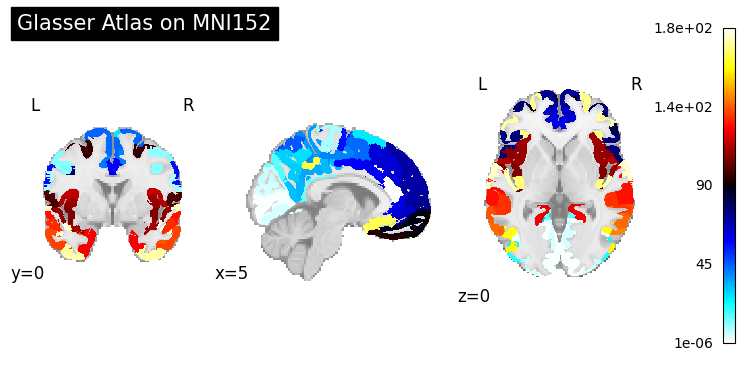

In [5]:
import nilearn.plotting as nplt

nplt.plot_stat_map(glasser_mni, title='Glasser Atlas on MNI152', display_mode='ortho', cut_coords=(5, 0, 0), colorbar=True, draw_cross=False)


In [ ]:
# creating glasser parcel unique in each hemisphere


im_parcel_data = glasser_mni.get_fdata()
im_parcel_data = np.round(im_parcel_data).astype(int)
print(len(np.unique(im_parcel_data)))
print(np.shape(im_parcel_data))

dims = im_parcel_data.shape

#im_parcel_data_left = im_parcel_data[:, :dims[1] // 2, :]
#im_parcel_data_right = im_parcel_data[:, dims[1] // 2:, :]
im_parcel_data_left = im_parcel_data[:dims[0] // 2  , :, :]
im_parcel_data_right = im_parcel_data[dims[0] // 2: , :, :]

im_parcel_data_left_unique = im_parcel_data_left #+ 1000
im_parcel_data_right_unique = im_parcel_data_right + 180
# but set 0 to 0 again for right hemisphere ?
im_parcel_data_right_unique[im_parcel_data_right_unique == 180] = 0

im_parcel_both_unique = np.concatenate((im_parcel_data_left_unique, im_parcel_data_right_unique), axis=0)
im_parcel_both_unique =im_parcel_both_unique.astype(float)

glasser_mni_unique = nib.Nifti1Image(im_parcel_both_unique, glasser_mni.affine, glasser_mni.header)

glassser_atlas_name_unique = op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/GlasserParcellationAtlas_MNI/HCP-MMP1_on_MNI152_ICBM2009a_nlin_hemi-unique.nii.gz')
#glasser_mni_unique.to_filename(glassser_atlas_name_unique)

181
(197, 233, 189)


In [18]:
len(np.unique(im_parcel_both_unique))

361

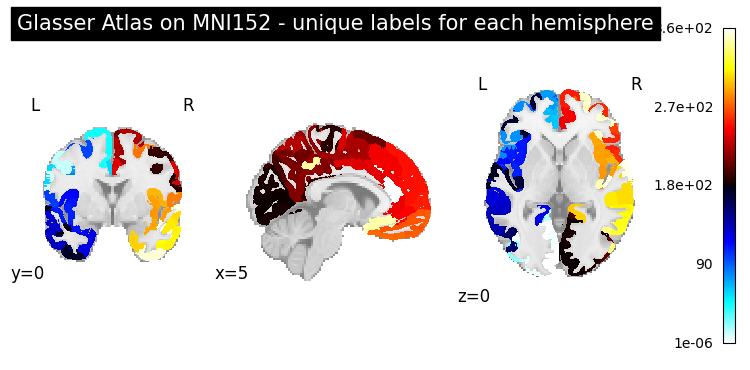

In [22]:
nplt.plot_stat_map(glasser_mni_unique, title='Glasser Atlas on MNI152 - unique labels for each hemisphere', display_mode='ortho', cut_coords=(5, 0, 0), colorbar=True, draw_cross=False)


In [10]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

# plot parcel
from brainspace.utils.parcellation import map_to_labels, reduce_by_labels
from matplotlib.colors import ListedColormap
import hcp_utils as hcp
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])

network_label = 5 # dorsal-attention
cmap_two = ListedColormap(['white',rgb[network_label-1] ], 'custom_colormap')

mapping = glasser_CAatlas_mapping.reset_index().copy()
mapping['glasser_parcel'] += 1
parcels_of_interest = mapping[mapping['ca_network'] == network_label]['glasser_parcel'].values

glassers_fsav5 = map_to_labels(mapping['glasser_parcel'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Text(0.5, 0.98, 'Pacel: 180')

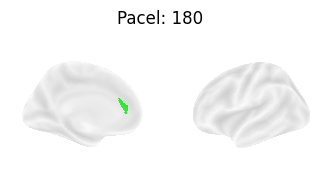

In [14]:
# from numrisk.gradients.groupComparison_02.ipynb
parcel_n = 180
hemi = 'L' # 'R'
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
fsaverage = fetch_surf_fsaverage() 

surf_mesh = fsaverage.infl_right if hemi == 'R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi == 'R' else fsaverage.sulc_left
map = np.split(glassers_fsav5,2)[1].astype(float) if hemi == 'R' else np.split(glassers_fsav5,2)[0].astype(float)# for i, hemi in enumerate(['L', 'R']): --> left firs

map[map != parcel_n] = 0 #np.nan
map[map == parcel_n] = 1
figure, axes = plt.subplots(nrows=1, ncols=2,figsize = (4,2), subplot_kw=dict(projection='3d'))
for i, view in enumerate(['medial','lateral']):
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view=view,cmap=cmap_two, colorbar=False, axes=axes[i],
                bg_map=bg_map, bg_on_data=True,darkness=0.7) #

figure.suptitle(f'Pacel: {parcel_n}')

### Plot on surface

does not work so good yet

In [2]:
from neuromaps import transforms


In [ ]:
glassser_atlas = op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/GlasserParcellationAtlas_MNI/HCP-MMP1_on_MNI152_ICBM2009a_nlin.nii.gz')
glasser_atlas_fsav = transforms.mni152_to_fsaverage(glassser_atlas, '10k')

In [19]:
aal3_atlas = op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/AAL3/amended/AAL3_amended.nii.gz')
aal3_atlas_fsav = transforms.mni152_to_fsaverage(aal3_atlas, '10k')

In [21]:
aal3_atlas_im = nib.load(aal3_atlas).get_fdata()

print(len(np.unique(aal3_atlas_im)))
np.unique(aal3_atlas_im)

163


array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,
        46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,
        57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,
        68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,
        79.,  80.,  83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,
        92.,  93.,  94.,  95.,  96.,  97.,  98.,  99., 100., 101., 102.,
       103., 104., 105., 106., 107., 108., 109., 110., 111., 112., 113.,
       114., 115., 116., 117., 118., 119., 120., 121., 122., 123., 124.,
       125., 126., 127., 128., 129., 130., 131., 132., 135., 136., 137.,
       138., 139., 140., 141., 142., 143., 144., 145., 146., 147., 148.,
       149., 150., 151., 152., 153., 154., 155., 15

In [ ]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt

fsaverage = fetch_surf_fsaverage() # default 5
side_view = 'medial'
cmap = 'tab20b'

figure, axes = plt.subplots(nrows=1, ncols=1,figsize = (4,4), subplot_kw=dict(projection='3d'))
map_r = glasser_atlas_fsav[1].agg_data()

nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= map_r, # infl_right # pial_right
            view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
            bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes) #interpolation="nearest" ,
plt.show()

In [ ]:
# plot labels on brain surface

import nilearn.plotting as nlp

aal3_atlas = op.join('/mnt_AdaBD_largefiles//Data/SMILE_Data/DNumRisk/AAL3/AAL3v1_1mm.nii.gz')
nlp.view_img_on_surf(aal3_atlas, cmap='tab20b', threshold=0.5, colorbar=False, title='AAL3 Amended Atlas')

